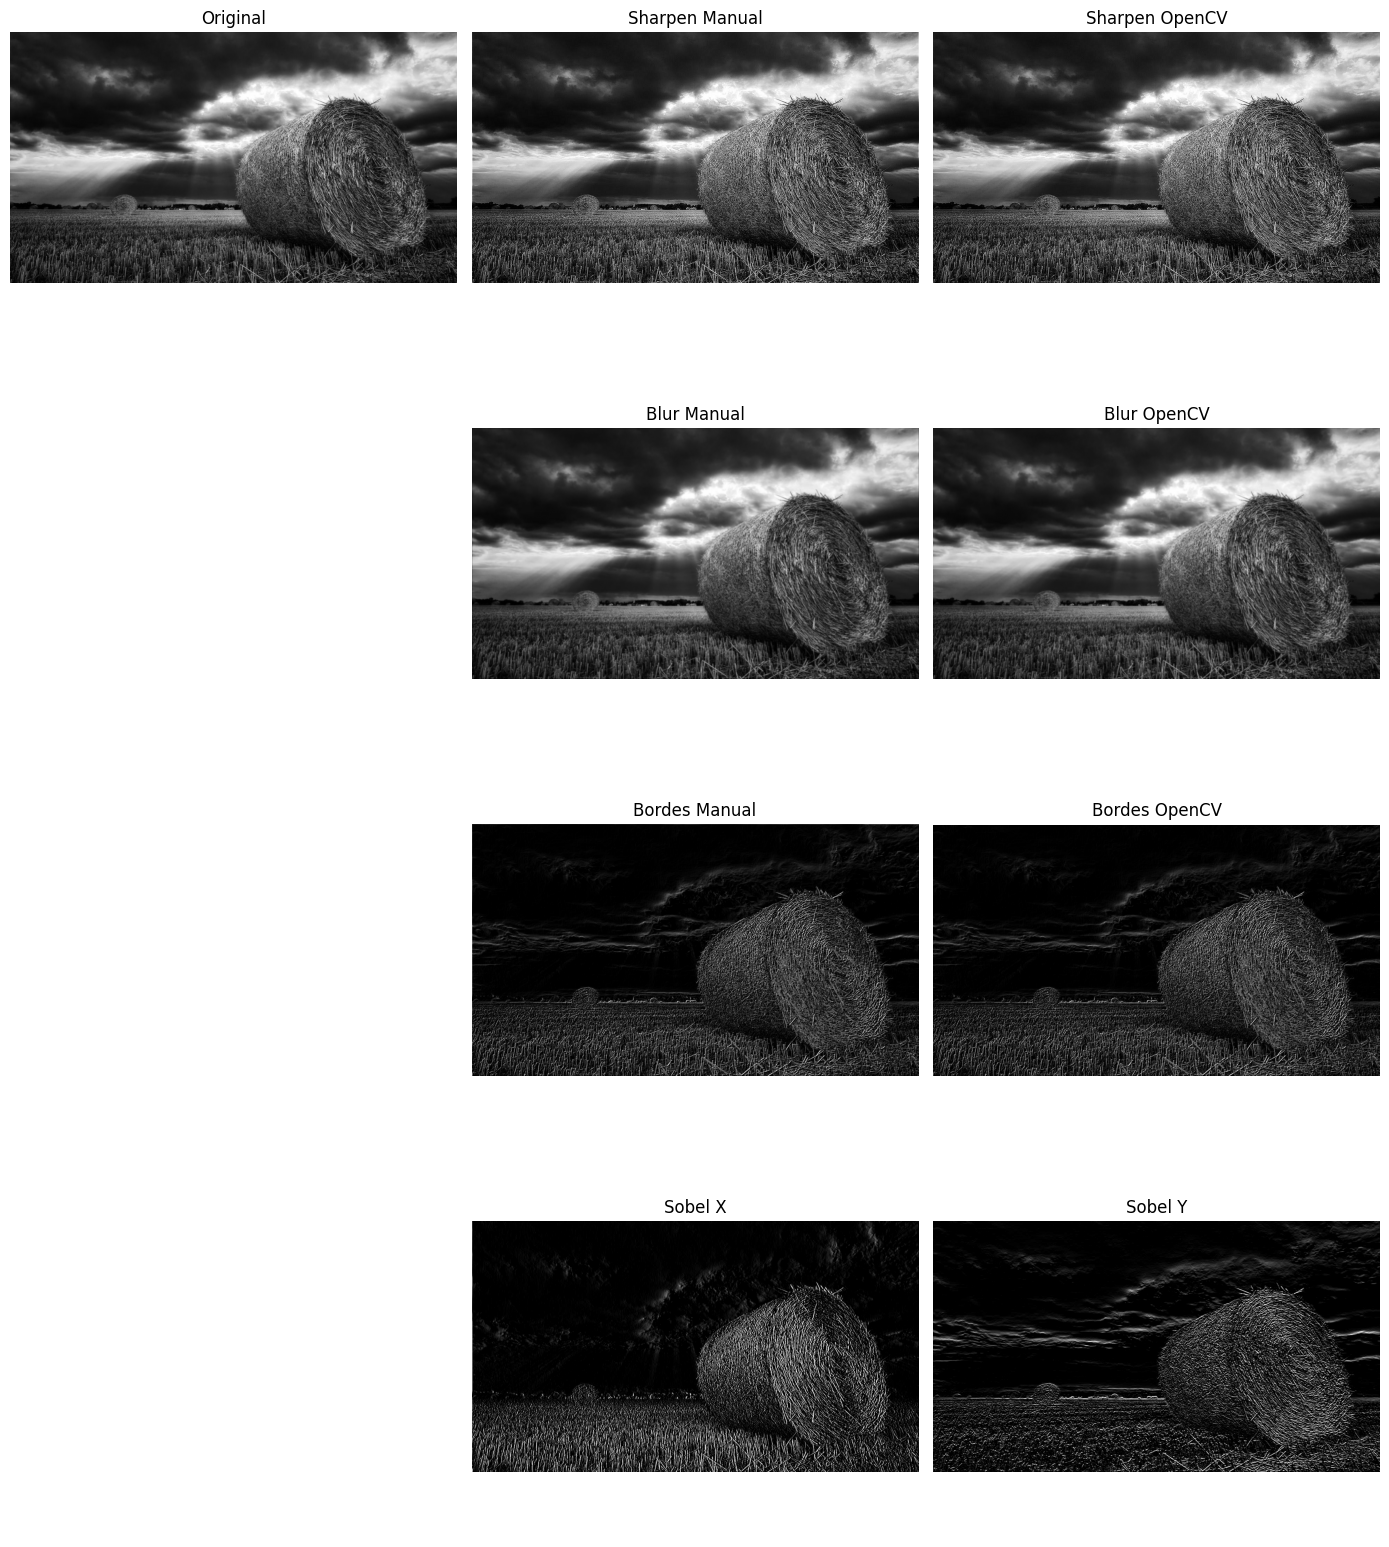

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# CARGAR IMAGEN EN ESCALA DE GRISES
# =========================================================

# Cambiar por la ruta de la imagen
imagen = cv2.imread("imagen.jpg", cv2.IMREAD_GRAYSCALE)

if imagen is None:
    raise Exception("No se pudo cargar la imagen")

# =========================================================
# FUNCION DE CONVOLUCION MANUAL
# =========================================================

def convolucion_manual(imagen, kernel):

    alto, ancho = imagen.shape
    k_alto, k_ancho = kernel.shape

    padding_y = k_alto // 2
    padding_x = k_ancho // 2

    # Agregar bordes de ceros
    imagen_padding = np.pad(
        imagen,
        ((padding_y, padding_y), (padding_x, padding_x)),
        mode='constant'
    )

    salida = np.zeros((alto, ancho), dtype=np.float32)

    # Recorrer cada pixel
    for y in range(alto):
        for x in range(ancho):

            # Extraer region
            region = imagen_padding[
                y:y+k_alto,
                x:x+k_ancho
            ]

            # Multiplicacion elemento a elemento
            valor = np.sum(region * kernel)

            salida[y, x] = valor

    # Limitar valores entre 0 y 255
    salida = np.clip(salida, 0, 255)

    return salida.astype(np.uint8)

# =========================================================
# KERNELS PERSONALIZADOS
# =========================================================

# 1. SHARPENING (ENFOQUE)
kernel_sharpen = np.array([
    [ 0, -1,  0],
    [-1,  5, -1],
    [ 0, -1,  0]
])

# 2. BLUR (SUAVIZADO)
kernel_blur = (1/9) * np.array([
    [1, 1, 1],
    [1, 1, 1],
    [1, 1, 1]
])

# 3. DETECCION DE BORDES (SOBEL X)
kernel_sobel_x = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
])

# 4. DETECCION DE BORDES (SOBEL Y)
kernel_sobel_y = np.array([
    [-1, -2, -1],
    [ 0,  0,  0],
    [ 1,  2,  1]
])

# =========================================================
# APLICAR CONVOLUCION MANUAL
# =========================================================

imagen_sharpen_manual = convolucion_manual(imagen, kernel_sharpen)
imagen_blur_manual = convolucion_manual(imagen, kernel_blur)

sobel_x = convolucion_manual(imagen, kernel_sobel_x)
sobel_y = convolucion_manual(imagen, kernel_sobel_y)

# Magnitud del gradiente (bordes/esquinas)
imagen_bordes_manual = cv2.addWeighted(sobel_x, 0.5, sobel_y, 0.5, 0)

# =========================================================
# COMPARACION CON OPENCV
# =========================================================

imagen_sharpen_cv = cv2.filter2D(imagen, -1, kernel_sharpen)
imagen_blur_cv = cv2.filter2D(imagen, -1, kernel_blur)

sobel_x_cv = cv2.filter2D(imagen, -1, kernel_sobel_x)
sobel_y_cv = cv2.filter2D(imagen, -1, kernel_sobel_y)

imagen_bordes_cv = cv2.addWeighted(sobel_x_cv, 0.5, sobel_y_cv, 0.5, 0)

# =========================================================
# MOSTRAR RESULTADOS
# =========================================================

fig, axes = plt.subplots(4, 3, figsize=(14, 16))

# ORIGINAL
axes[0, 0].imshow(imagen, cmap='gray')
axes[0, 0].set_title("Original")
axes[0, 0].axis("off")

# SHARPEN MANUAL
axes[0, 1].imshow(imagen_sharpen_manual, cmap='gray')
axes[0, 1].set_title("Sharpen Manual")
axes[0, 1].axis("off")

# SHARPEN OPENCV
axes[0, 2].imshow(imagen_sharpen_cv, cmap='gray')
axes[0, 2].set_title("Sharpen OpenCV")
axes[0, 2].axis("off")

# BLUR MANUAL
axes[1, 1].imshow(imagen_blur_manual, cmap='gray')
axes[1, 1].set_title("Blur Manual")
axes[1, 1].axis("off")

# BLUR OPENCV
axes[1, 2].imshow(imagen_blur_cv, cmap='gray')
axes[1, 2].set_title("Blur OpenCV")
axes[1, 2].axis("off")

# BORDES MANUAL
axes[2, 1].imshow(imagen_bordes_manual, cmap='gray')
axes[2, 1].set_title("Bordes Manual")
axes[2, 1].axis("off")

# BORDES OPENCV
axes[2, 2].imshow(imagen_bordes_cv, cmap='gray')
axes[2, 2].set_title("Bordes OpenCV")
axes[2, 2].axis("off")

# SOBEL X
axes[3, 1].imshow(sobel_x, cmap='gray')
axes[3, 1].set_title("Sobel X")
axes[3, 1].axis("off")

# SOBEL Y
axes[3, 2].imshow(sobel_y, cmap='gray')
axes[3, 2].set_title("Sobel Y")
axes[3, 2].axis("off")

# Espacios vacios
axes[1, 0].axis("off")
axes[2, 0].axis("off")
axes[3, 0].axis("off")

plt.tight_layout()
plt.show()

# Bonus

Se abrirá una ventana llamada Filtro.

In [7]:
import cv2
import numpy as np

imagen = cv2.imread("imagen.jpg", cv2.IMREAD_GRAYSCALE)

def actualizar(x):

    valor = cv2.getTrackbarPos("Intensidad", "Filtro")

    kernel = np.array([
        [0, -1, 0],
        [-1, 4 + valor, -1],
        [0, -1, 0]
    ])

    resultado = cv2.filter2D(imagen, -1, kernel)

    cv2.imshow("Filtro", resultado)

cv2.namedWindow("Filtro")

cv2.createTrackbar(
    "Intensidad",
    "Filtro",
    1,
    10,
    actualizar
)

actualizar(0)

cv2.waitKey(0)
cv2.destroyAllWindows()